In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [41]:
df = pd.read_csv("CDD CSV Export - 2025-10-30 02h44m52s.csv")

df

,Molecule Name,CDD Number,SARS-CoV-2-MPro_fluorescence-dose-response_weizmann: IC50 (µM),MERS-CoV-MPro_fluorescence-dose-response_weizmann: IC50 (µM)
0,ASAP-0032605,NaN,1.701,(IC50 could not be calculated)
1,ASAP-0032604,NaN,2.593,(IC50 could not be calculated)
2,ASAP-0032572,NaN,6.562,> 99.500
3,ASAP-0032562,NaN,> 99.500,> 99.500
4,ASAP-0032561,NaN,63.711,(IC50 could not be calculated)
...,...,...,...,...
2071,ASAP-0000143,NaN,NaN,> 9.990
2072,ASAP-0000142,NaN,5.157,> 99.500
2073,ASAP-0000142,NaN,NaN,> 9.990
2074,ASAP-0000141,NaN,> 9.990,> 99.500


In [50]:
sars2_control_ic50s = []

for group, groupdf in df[["Molecule Name", "SARS-CoV-2-MPro_fluorescence-dose-response_weizmann: IC50 (µM)"]].groupby(by="Molecule Name"):
    if len(groupdf) > 10:
        groupdf = groupdf[groupdf["SARS-CoV-2-MPro_fluorescence-dose-response_weizmann: IC50 (µM)"] != "(IC50 could not be calculated)"]
        groupdf = groupdf.dropna()
        groupdf = groupdf[~groupdf["SARS-CoV-2-MPro_fluorescence-dose-response_weizmann: IC50 (µM)"].str.contains(">")]
        groupdf = groupdf[~groupdf["SARS-CoV-2-MPro_fluorescence-dose-response_weizmann: IC50 (µM)"].str.contains("<")]
        print(group)
        for val in groupdf["SARS-CoV-2-MPro_fluorescence-dose-response_weizmann: IC50 (µM)"].values:
            if -np.log10(float(val)/1000000) < 7.5:
                continue # remove outlier
            
            sars2_control_ic50s.append(-np.log10(float(val)/1000000))

ASAP-0000153


In [51]:
mers_control_ic50s = []

for group, groupdf in df[["Molecule Name", "MERS-CoV-MPro_fluorescence-dose-response_weizmann: IC50 (µM)"]].groupby(by="Molecule Name"):
    if len(groupdf) > 10:
        print(group)
        groupdf = groupdf[groupdf["MERS-CoV-MPro_fluorescence-dose-response_weizmann: IC50 (µM)"] != "(IC50 could not be calculated)"]
        groupdf = groupdf.dropna()
        groupdf = groupdf[~groupdf["MERS-CoV-MPro_fluorescence-dose-response_weizmann: IC50 (µM)"].str.contains(">")]
        groupdf = groupdf[~groupdf["MERS-CoV-MPro_fluorescence-dose-response_weizmann: IC50 (µM)"].str.contains("<")]
        for val in groupdf["MERS-CoV-MPro_fluorescence-dose-response_weizmann: IC50 (µM)"].values:
            
            mers_control_ic50s.append(-np.log10(float(val)/1000000))

ASAP-0000153


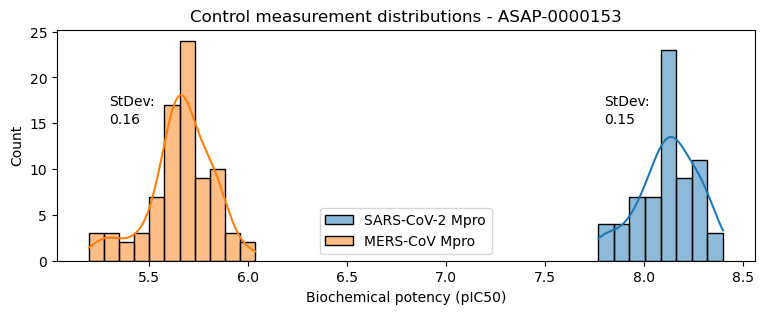

In [61]:
f, ax = plt.subplots(figsize=(9,3))


sns.histplot(sars2_control_ic50s, kde=True, ax=ax, label="SARS-CoV-2 Mpro")
sns.histplot(mers_control_ic50s, kde=True, ax=ax, label="MERS-CoV Mpro")

ax.annotate(f"StDev:", xy=(7.8, 17))
ax.annotate(f"{np.std(sars2_control_ic50s):.2f}", xy=(7.8, 15))

ax.annotate(f"StDev:", xy=(5.3, 17))
ax.annotate(f"{np.std(mers_control_ic50s):.2f}", xy=(5.3, 15))

ax.set_title("Control measurement distributions - ASAP-0000153")
ax.set_xlabel("Biochemical potency (pIC50)")
plt.legend()
plt.savefig("wis_control_distributions.png", dpi=300, bbox_inches="tight")